In [1]:
"""
Tonality Distribution Analysis
==============================

This script walks through the `dataset_2` directory, reads every
`*_normalized.json` file contained in the **lastfm**, **suno**, and **udio**
collections, discovers the top‑level keys present, counts each song’s
**tonality** (taken from the first chord object), and then visualises the
results with a **grouped bar chart** so you can compare tendencies among the
three collections.

*Tonality rows are sorted from highest to lowest using **lastfm** counts as the
reference.*

Run it in a Jupyter notebook **or** as a standalone script:

```bash
# Inside a notebook cell ──────────────────────────────
%run tonality_distribution.py

# Or from the command line  ──────────────────────────
python tonality_distribution.py
```
"""
from __future__ import annotations

import glob
import json
import os
from collections import Counter, defaultdict
from typing import Dict, List, Set

from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Fallback `display` so the script works outside IPython
# ---------------------------------------------------------------------------
try:
    from IPython.display import display  # type: ignore
except ImportError:  # Running outside Jupyter

    def display(obj):  # type: ignore  # noqa: D401, ANN001
        """Plain‑text fallback when rich display is unavailable."""

        print(obj)

# ---------------------------------------------------------------------------
# Configuration – change BASE_DIR if your data lives elsewhere
# ---------------------------------------------------------------------------
BASE_DIR: str = "/workspace/dataset_2"
COLLECTIONS: List[str] = ["lastfm", "suno", "udio"]
COLORS: List[str] = ["#51BFFF", "#FFC400", "#FF5B0E"]  # Colour palette

# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------

def scan_collections(
    base_dir: str = BASE_DIR, collections: List[str] = COLLECTIONS
):
    """Walk each collection, gathering schema keys and tonality counts."""

    all_keys: Dict[str, Set[str]] = defaultdict(set)
    tonality_counts: Dict[str, Counter] = defaultdict(Counter)

    for collection in tqdm(collections, desc="Collections"):
        pattern = os.path.join(base_dir, collection, "*", "*_normalized.json")
        for filepath in glob.glob(pattern):
            try:
                with open(filepath, "r", encoding="utf-8") as f:
                    data = json.load(f)
            except Exception as exc:  # noqa: BLE001
                print(f"⚠️  Could not read {filepath}: {exc}")
                continue

            # Record every top‑level key present in the file
            all_keys[collection].update(data.keys())

            # Extract tonality (constant across the song) from the first chord
            chords = data.get("chords", [])
            if chords:
                tonality = chords[0].get("tonality")
                if tonality:
                    tonality_counts[collection][tonality] += 1

    return all_keys, tonality_counts


def build_dataframe(
    tonality_counts: Dict[str, Counter], collections: List[str] = COLLECTIONS
) -> pd.DataFrame:
    """Convert nested counters into a tidy DataFrame (tonality × collection)."""

    all_tonalities = sorted({t for counter in tonality_counts.values() for t in counter})
    df = pd.DataFrame(index=all_tonalities, columns=collections).fillna(0)

    for collection, counter in tonality_counts.items():
        for tonality, count in counter.items():
            df.loc[tonality, collection] = count

    return df.astype(int)


In [2]:
# 1. Scan JSON files
all_keys, tonality_counts = scan_collections()



Collections:   0%|          | 0/3 [00:00<?, ?it/s]

Collections: 100%|██████████| 3/3 [00:49<00:00, 16.34s/it]


In [3]:
tonality_counts

defaultdict(collections.Counter,
            {'lastfm': Counter({'E minor': 2046,
                      'A minor': 1792,
                      'D minor': 1739,
                      'G minor': 1365,
                      'C minor': 1165,
                      'B minor': 1108,
                      'F# minor': 1078,
                      'C# minor': 1028,
                      'F minor': 967,
                      'D major': 901,
                      'G# minor': 798,
                      'C major': 780,
                      'D# minor': 769,
                      'G major': 749,
                      'A major': 633,
                      'Bb minor': 630,
                      'E major': 538,
                      'F major': 365,
                      'Eb major': 310,
                      'Db major': 296,
                      'B major': 283,
                      'Bb major': 228,
                      'F# major': 219,
                      'Ab major': 218}),
             'suno': Coun

Top‑level keys per collection:
 lastfm: ['beats', 'bound_frames', 'bound_segments', 'bound_times', 'chords', 'sr']
 suno: ['beats', 'bound_frames', 'bound_segments', 'bound_times', 'chords', 'sr']
 udio: ['beats', 'bound_frames', 'bound_segments', 'bound_times', 'chords', 'sr']


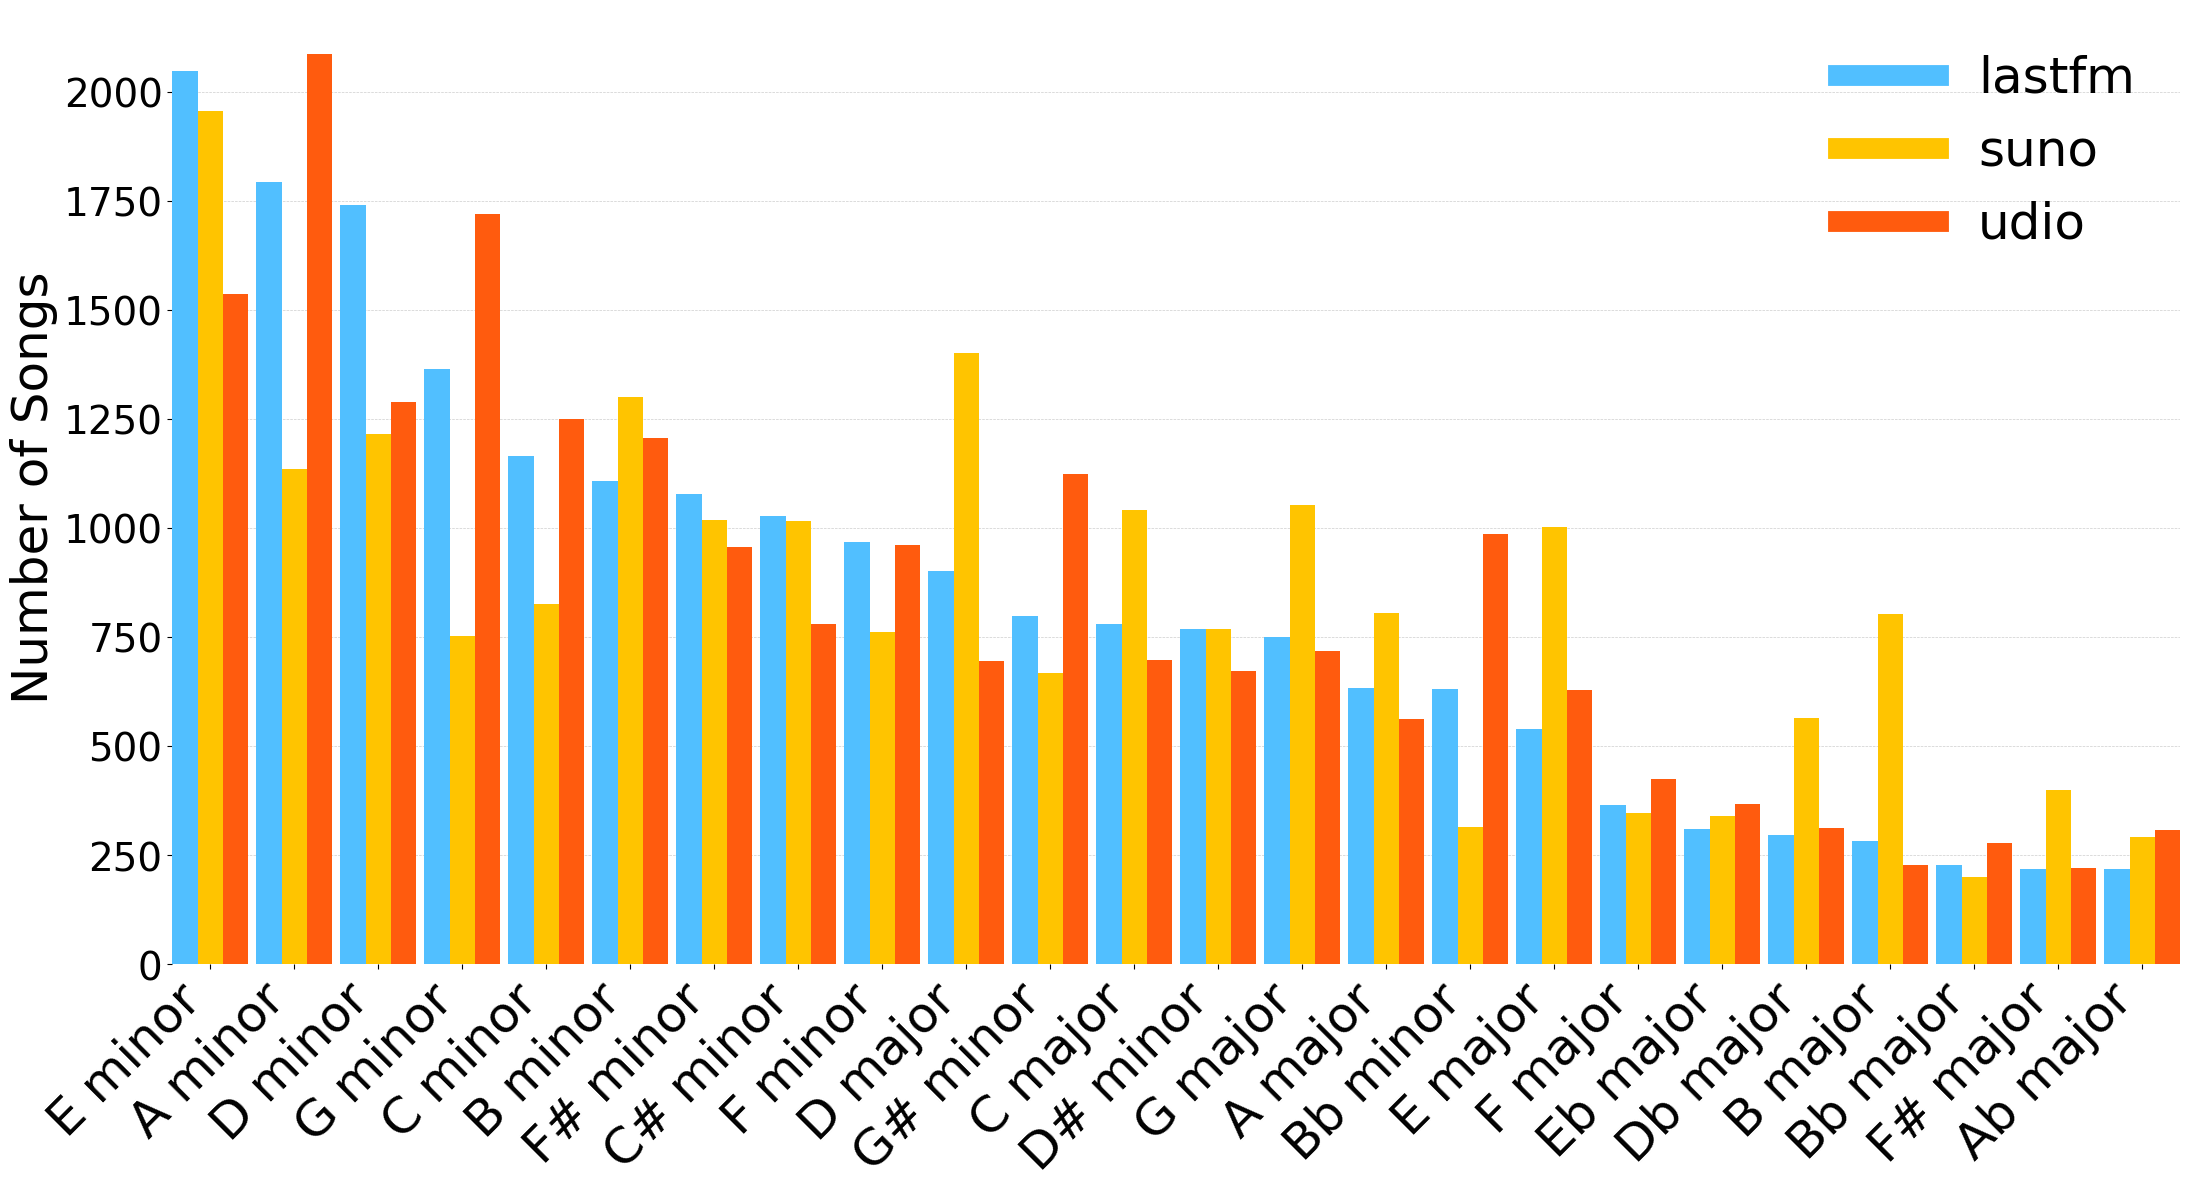

In [9]:
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------------
# 2. Print discovered schema keys
print("Top‑level keys per collection:")
for col, keys in all_keys.items():
    print(f" {col}: {sorted(keys)}")

# 3. Build tonality × collection matrix
df = build_dataframe(tonality_counts)

# 3a. Sort tonalities by **lastfm** counts (descending)
if "lastfm" in df.columns:
    df = df.sort_values(by="lastfm", ascending=False)

# 4. Grouped bar chart with specified colours and tighter layout
x = np.arange(len(df.index))  # positions for tonality groups
bar_width = 0.9 / len(COLLECTIONS)
text_size = 36
legend_size = 36

fig, ax = plt.subplots(figsize=(22, 12))

for idx, (col, color) in enumerate(zip(COLLECTIONS, COLORS)):
    offsets = (idx - (len(COLLECTIONS) - 1) / 2) * bar_width
    positions = x + offsets
    ax.bar(
        positions,
        df[col],
        width=bar_width,
        color=color,
        label=col,
        alpha=1.0,
    )

ax.set_axisbelow(True)  # grid behind the bars
ax.grid(axis='y',  # only horizontal lines
        linestyle='--',  # dashed
        linewidth=0.5,
        color="#cdcdcd",
        alpha=1.0)

# Remove frame/spines that are not needed
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Eliminate empty borders at each end of the x‑axis
ax.margins(x=0)  # no horizontal padding

# Tick labels and title
ax.set_xticks(x)
ax.tick_params(axis="y", labelsize=28)
ax.set_xticklabels(df.index, rotation=45, ha="right", fontsize=text_size)
ax.set_xlabel("", fontsize=text_size)
ax.set_ylabel("Number of Songs", fontsize=text_size)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

# FIX: Move legend inside the plot area to eliminate white space
ax.legend([Line2D([0], [0], color=c, lw=15) for c in COLORS], COLLECTIONS,
          fontsize=legend_size, loc="upper right", frameon=False)  # Changed to upper right, removed bbox_to_anchor

plt.tight_layout()
plt.show()

In [5]:
"""
Tonality Distribution Analysis
==============================

This script walks through the `dataset_2` directory, reads every
`*_normalized.json` file contained in the **lastfm**, **suno**, and **udio**
collections, counts each song’s **tonality** (taken from the first chord
object), and visualises the results:

1. **Grouped bar chart** comparing collections (tonalities sorted by _lastfm_)
2. **Stacked bar chart** showing tonality distribution per **dominant
   Dortmund genre** (if the corresponding `*_style.json` exists)

Run it in a Jupyter notebook **or** as a standalone script:

```bash
# Inside a notebook cell ──────────────────────────────
%run tonality_distribution.py

# Or from the command line  ──────────────────────────
python tonality_distribution.py
```
"""
from __future__ import annotations

import glob
import json
import os
from collections import Counter, defaultdict
from typing import Dict, List, Set

from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Fallback `display` so the script works outside IPython
# ---------------------------------------------------------------------------
try:
    from IPython.display import display  # type: ignore
except ImportError:  # Running outside Jupyter

    def display(obj):  # type: ignore  # noqa: D401, ANN001
        """Plain‑text fallback when rich display is unavailable."""

        print(obj)

# ---------------------------------------------------------------------------
# Configuration – change BASE_DIR if your data lives elsewhere
# ---------------------------------------------------------------------------
BASE_DIR: str = "/workspace/dataset_2"
COLLECTIONS: List[str] = ["lastfm", "suno", "udio"]
COLORS: List[str] = ["#51BFFF", "#FFC400", "#FF5B0E"]  # lastfm, suno, udio

# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------

def dominant_genre(genre_dict: Dict[str, str]) -> str:
    """Return the genre key with the highest score (float cast)."""

    return max(genre_dict.items(), key=lambda kv: float(kv[1]))[0]


def scan_collections(
    base_dir: str = BASE_DIR, collections: List[str] = COLLECTIONS
):
    """Walk each collection, gather schema keys, tonality counts, and
    tonality counts **per dominant Dortmund genre**."""

    all_keys: Dict[str, Set[str]] = defaultdict(set)
    tonality_counts: Dict[str, Counter] = defaultdict(Counter)
    tonality_by_style: Dict[str, Counter] = defaultdict(Counter)

    for collection in tqdm(collections, desc="Collections"):
        pattern = os.path.join(base_dir, collection, "*", "*_normalized.json")
        for filepath in glob.glob(pattern):
            # ------------------- read normalized ---------------------------
            try:
                with open(filepath, "r", encoding="utf-8") as f:
                    data = json.load(f)
            except Exception as exc:  # noqa: BLE001
                print(f"⚠️  Could not read {filepath}: {exc}")
                continue

            all_keys[collection].update(data.keys())

            chords = data.get("chords", [])
            tonality = chords[0].get("tonality") if chords else None
            if tonality:
                tonality_counts[collection][tonality] += 1

            # ------------------- read style -------------------------------
            style_path = filepath.replace("_normalized.json", "_style.json")
            style = "unknown"
            if os.path.isfile(style_path):
                try:
                    with open(style_path, "r", encoding="utf-8") as sf:
                        style_data = json.load(sf)
                    genre_dict = style_data.get("genre_dortmund", {})
                    if genre_dict:
                        style = dominant_genre(genre_dict)
                except Exception as exc:
                    print(f"⚠️  Could not read {style_path}: {exc}")
            # accumulate tonality per style (skip if tonality missing)
            if tonality:
                tonality_by_style[style][tonality] += 1

    return all_keys, tonality_counts, tonality_by_style


def build_dataframe(
    tonality_counts: Dict[str, Counter], collections: List[str] = COLLECTIONS
) -> pd.DataFrame:
    """Convert nested counters into a tidy DataFrame (tonality × collection)."""

    all_tonalities = sorted({t for c in tonality_counts.values() for t in c})
    df = pd.DataFrame(index=all_tonalities, columns=collections).fillna(0)
    for collection, counter in tonality_counts.items():
        for tonality, count in counter.items():
            df.loc[tonality, collection] = count
    return df.astype(int)


def build_style_dataframe(tonality_by_style: Dict[str, Counter]) -> pd.DataFrame:
    """Convert tonality‑by‑style counters into DataFrame (tonality × style)."""

    if not tonality_by_style:
        return pd.DataFrame()

    all_tonalities = sorted({t for c in tonality_by_style.values() for t in c})
    styles = sorted(tonality_by_style.keys())
    df_style = pd.DataFrame(index=all_tonalities, columns=styles).fillna(0)
    for style, counter in tonality_by_style.items():
        for tonality, count in counter.items():
            df_style.loc[tonality, style] = count
    return df_style.astype(int)

# ---------------------------------------------------------------------------
# Main (runs when executed as a script or via %run)
# ---------------------------------------------------------------------------

# 1. Scan data
all_keys, tonality_counts, tonality_by_style = scan_collections()

Collections:   0%|          | 0/3 [00:00<?, ?it/s]

Collections: 100%|██████████| 3/3 [01:35<00:00, 31.98s/it]


Top‑level keys per collection:
  lastfm: ['beats', 'bound_frames', 'bound_segments', 'bound_times', 'chords', 'sr']
  suno: ['beats', 'bound_frames', 'bound_segments', 'bound_times', 'chords', 'sr']
  udio: ['beats', 'bound_frames', 'bound_segments', 'bound_times', 'chords', 'sr']

Tonalities × Collections matrix (sorted by lastfm):


,lastfm,suno,udio
E minor,2046,1955,1537
A minor,1792,1135,2085
D minor,1739,1215,1289
G minor,1365,752,1719
C minor,1165,826,1249
B minor,1108,1301,1207
F# minor,1078,1018,957
C# minor,1028,1016,779
F minor,967,762,961
D major,901,1400,694


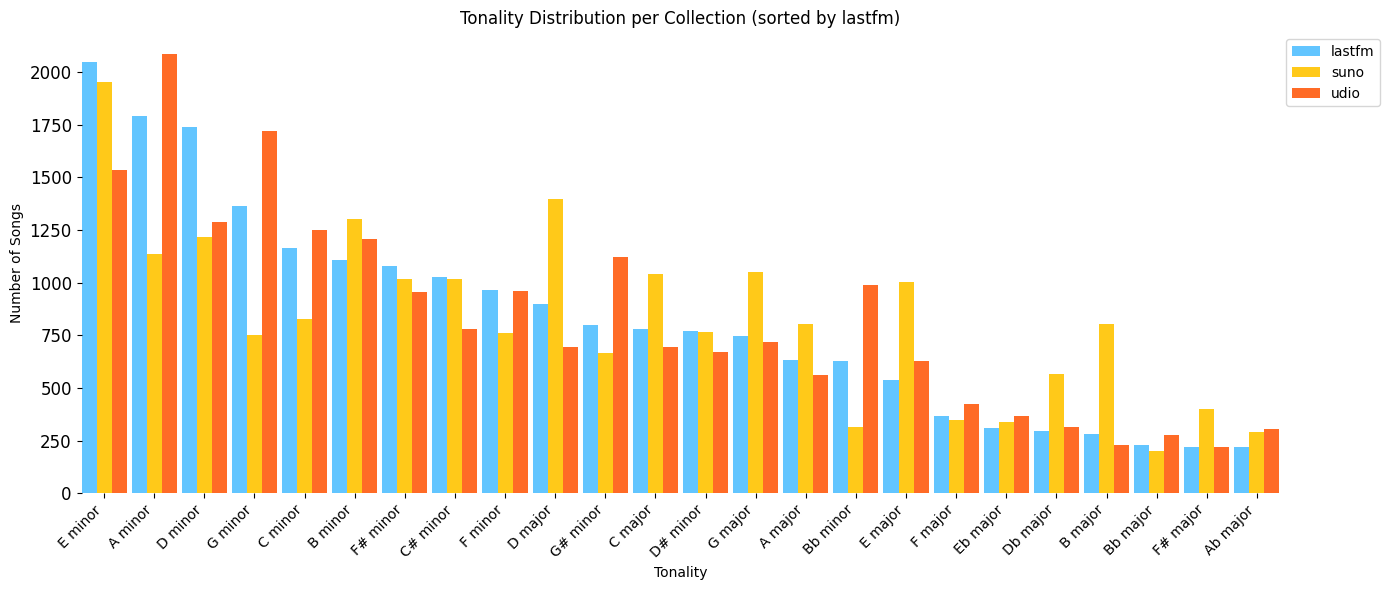

In [6]:
# 2. Collections‑level tonality table
df = build_dataframe(tonality_counts)
if "lastfm" in df.columns:
    df = df.sort_values(by="lastfm", ascending=False)

print("Top‑level keys per collection:")
for col, keys in all_keys.items():
    print(f"  {col}: {sorted(keys)}")

print("\nTonalities × Collections matrix (sorted by lastfm):")
display(df)

# 3. Grouped bar chart (collections)
x = np.arange(len(df))
bar_width = 0.9 / len(COLLECTIONS)

fig, ax = plt.subplots(figsize=(14, 6))
for idx, (col, color) in enumerate(zip(COLLECTIONS, COLORS)):
    positions = x + (idx - (len(COLLECTIONS) - 1) / 2) * bar_width
    ax.bar(positions, df[col], width=bar_width, color=color, label=col, alpha=0.9)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.margins(x=0)
ax.set_xticks(x)
ax.set_xticklabels(df.index, rotation=45, ha="right")
ax.set_xlabel("Tonality")
ax.set_ylabel("Number of Songs")
ax.tick_params(axis="y", labelsize=12)
ax.set_title("Tonality Distribution per Collection (sorted by lastfm)")
ax.legend(fontsize=10, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

/tmp/ipykernel_3677989/2230697978.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("cividis", len(all_tones))  # blue→orange gradient


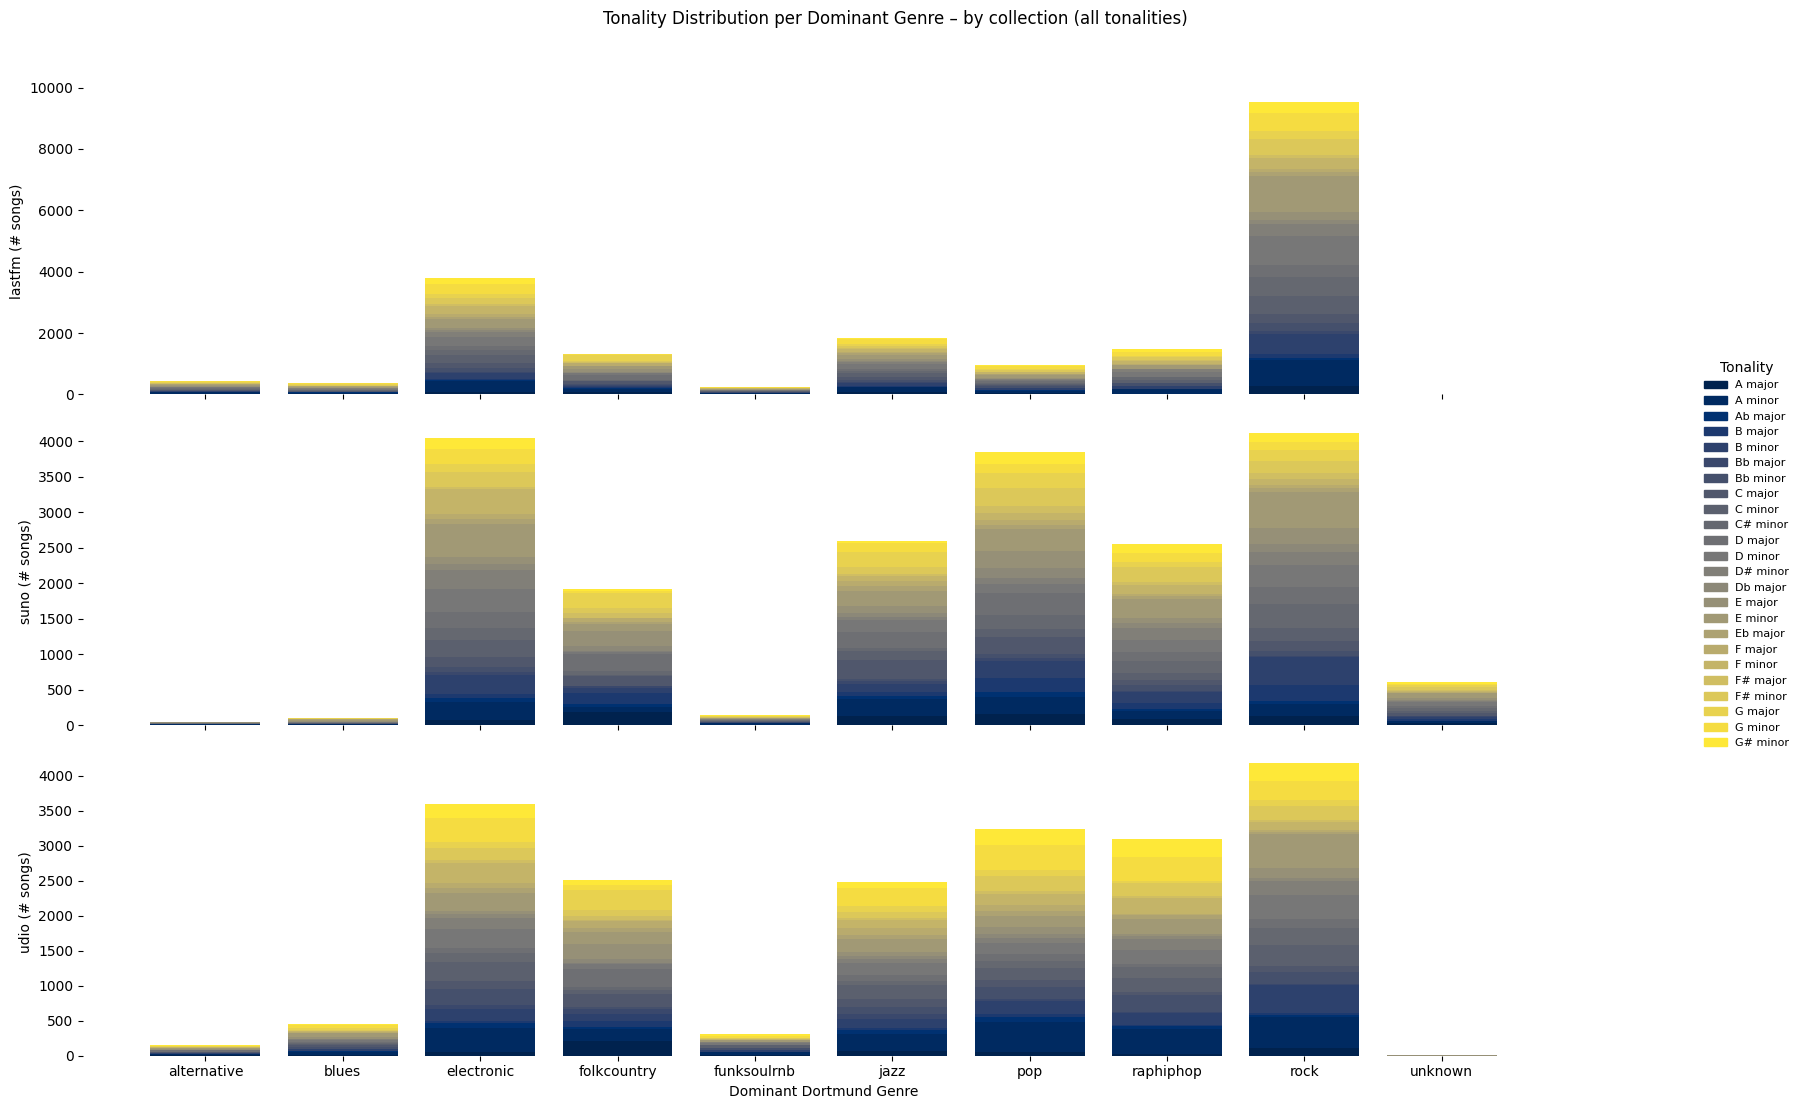

In [7]:
# 4. Style‑level tonality table & plot
# --------------------------------------------------------------------
# 4. Tonality distribution **per dominant Dortmund genre**
#    – broken down by collection, all tonalities shown –
# --------------------------------------------------------------------
if tonality_by_style:
    # 4a. Build nested counters: collection × style × tonality
    style_coll_ton: Dict[str, Dict[str, Counter]] = defaultdict(lambda: defaultdict(Counter))
    for collection in COLLECTIONS:
        pattern = os.path.join(BASE_DIR, collection, "*", "*_normalized.json")
        for filepath in glob.glob(pattern):
            with open(filepath, "r", encoding="utf-8") as f:
                data = json.load(f)
            chords = data.get("chords", [])
            ton = chords[0].get("tonality") if chords else None
            if not ton:
                continue

            style_path = filepath.replace("_normalized.json", "_style.json")
            if os.path.isfile(style_path):
                with open(style_path, "r", encoding="utf-8") as sf:
                    gdict = json.load(sf).get("genre_dortmund", {})
                style = dominant_genre(gdict) if gdict else "unknown"
            else:
                style = "unknown"

            style_coll_ton[collection][style][ton] += 1

    # 4b. Lists & colours
    styles = sorted({s for coll in style_coll_ton.values() for s in coll})
    present_colls = [c for c in COLLECTIONS if c in style_coll_ton]
    all_tones = sorted({t for coll in style_coll_ton.values() for sty in coll.values() for t in sty})

    cmap = plt.cm.get_cmap("cividis", len(all_tones))  # blue→orange gradient
    tone_colors = {tone: cmap(i) for i, tone in enumerate(all_tones)}

    # 4c. Plot rows per collection
    fig, axes = plt.subplots(
        nrows=len(present_colls), figsize=(18, 4 * len(present_colls)), sharex=True
    )
    if len(present_colls) == 1:
        axes = [axes]

    for ax, coll in zip(axes, present_colls):
        df_coll = pd.DataFrame(index=styles, columns=all_tones).fillna(0)
        for sty in styles:
            counter = style_coll_ton[coll].get(sty, Counter())
            for ton, cnt in counter.items():
                df_coll.at[sty, ton] = cnt

        bottom = np.zeros(len(styles))
        for tone in all_tones:
            values = df_coll[tone].to_numpy()
            ax.bar(styles, values, bottom=bottom, color=tone_colors[tone], edgecolor="none")
            bottom += values

        ax.set_ylabel(f"{coll} (# songs)")
        for spine in ax.spines.values():
            spine.set_visible(False)

    axes[-1].set_xlabel("Dominant Dortmund Genre")
    fig.suptitle("Tonality Distribution per Dominant Genre – by collection (all tonalities)", y=0.92)
    fig.tight_layout(rect=[0, 0, 0.88, 0.9])

    handles = [plt.Rectangle((0, 0), 1, 1, color=tone_colors[t]) for t in all_tones]
    fig.legend(handles, all_tones, title="Tonality", loc="center right", frameon=False, ncol=1, fontsize=8)

    plt.show()